CANCER CLASSIFICATION USING CNN (STRATIFIED K-FOLD + ROC)
Total Samples: 20244, Total Features: 67
Remaining Samples: 1039, Remaining Classes: 388
Selected Top 50 Genes

========== FOLD 1 ==========
Fold 1 Accuracy: 0.1700

========== FOLD 2 ==========
Fold 2 Accuracy: 0.1676

========== FOLD 3 ==========
Fold 3 Accuracy: 0.1647

Average Cross-Validation Accuracy: 0.1675


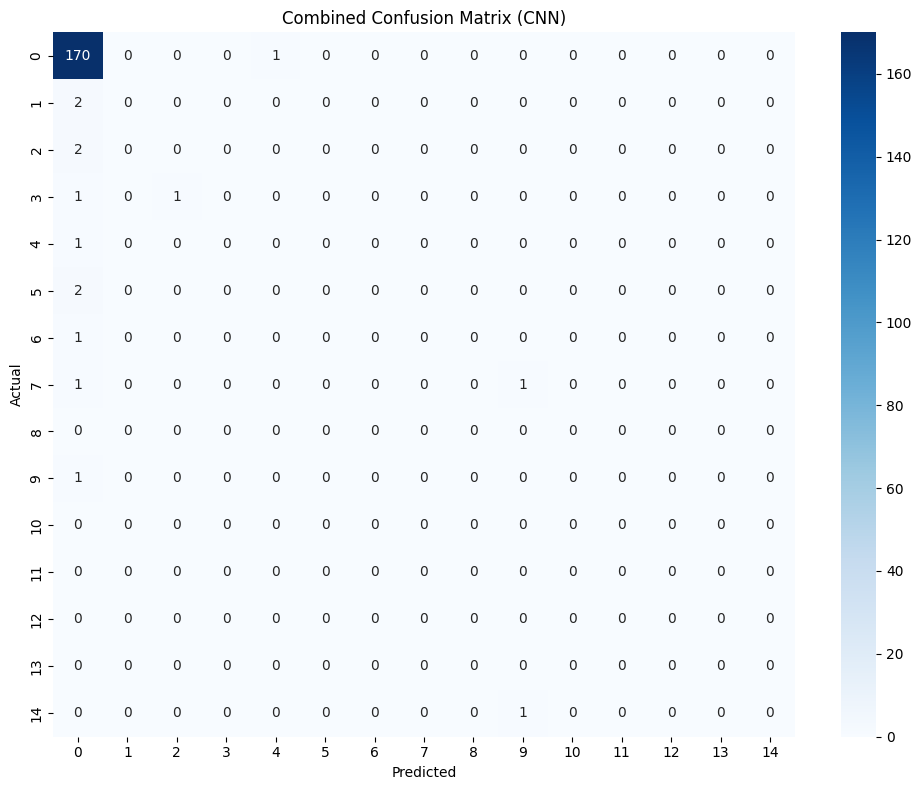


Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.98      0.90       173
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         2
           6       0.00      0.00      0.00         2
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         2
          11       0.00      0.00      0.00         2
          12       0.00      0.00      0.00         2
          13       0.00      0.00      0.00         2
          14       0.00      0.00      0.00         3
          15       0.00      0.00      0.00         2
          16       0.00      0.00      0.00         2
  

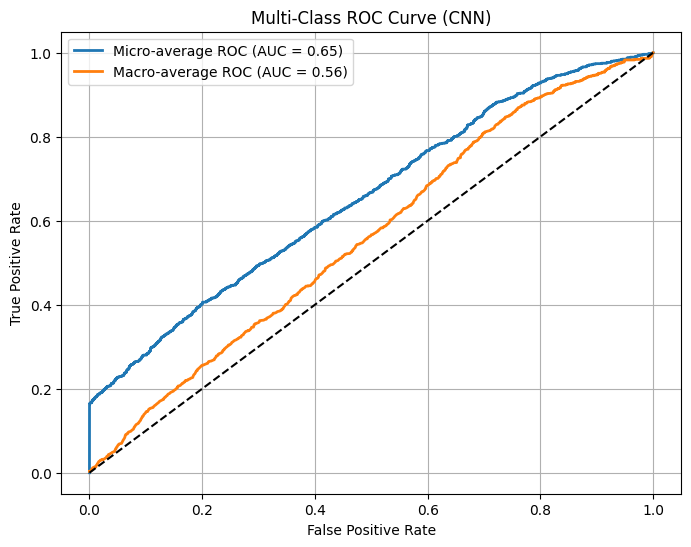


Micro AUC: 0.6530981140700054
Macro AUC: 0.5604346130875252

ANALYSIS COMPLETE ✅


In [ ]:
# ============================================================
# CANCER CLASSIFICATION USING CNN WITH CONFUSION MATRIX & ROC
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from itertools import cycle
import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
print("="*70)
print("CANCER CLASSIFICATION USING CNN (STRATIFIED K-FOLD + ROC)")
print("="*70)

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
data = pd.read_csv("Data_Sets.csv")
print(f"Total Samples: {data.shape[0]}, Total Features: {data.shape[1]-2}")

# ------------------------------------------------------------
# 2. PREPROCESSING
# ------------------------------------------------------------
X = data.iloc[:, 1:-1]
y = data.iloc[:, -1]

X = X.apply(pd.to_numeric, errors='coerce').fillna(X.median())

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Remove single-sample classes
class_counts = pd.Series(y_encoded).value_counts()
valid_classes = class_counts[class_counts >= 2].index
mask = np.isin(y_encoded, valid_classes)
X = X[mask]
y_encoded = y_encoded[mask]

# Re-encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_encoded)
class_names = le.classes_
n_classes = len(class_names)
print(f"Remaining Samples: {len(y_encoded)}, Remaining Classes: {n_classes}")

# Feature Selection
n_features = min(50, X.shape[1])
selector = SelectKBest(score_func=f_classif, k=n_features)
X_selected = selector.fit_transform(X, y_encoded)
print(f"Selected Top {n_features} Genes")

# ------------------------------------------------------------
# 3. DEFINE CNN MODEL
# ------------------------------------------------------------
class GeneCNN(nn.Module):
    def __init__(self, input_size, n_classes):
        super(GeneCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(64 * (input_size // 2), 128)
        self.fc2 = nn.Linear(128, n_classes)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.relu(self.bn2(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# ------------------------------------------------------------
# 4. STRATIFIED K-FOLD TRAINING
# ------------------------------------------------------------
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

fold_accuracies = []
all_preds = []
all_true = []
all_probs = []

fold_number = 1

for train_idx, test_idx in skf.split(X_selected, y_encoded):
    print(f"\n========== FOLD {fold_number} ==========")

    # Split
    X_train, X_test = X_selected[train_idx], X_selected[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    # Scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Convert to tensors
    X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
    X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
    y_train = torch.tensor(y_train, dtype=torch.long)
    y_test = torch.tensor(y_test, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

    # Model
    input_size = X_train.shape[2]
    model = GeneCNN(input_size, n_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training
    epochs = 15
    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Evaluation
    model.eval()
    y_pred = []
    y_true = []
    probs_fold = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            prob = torch.softmax(outputs, dim=1)
            probs_fold.extend(prob.numpy())
            _, predicted = torch.max(outputs, 1)
            y_pred.extend(predicted.numpy())
            y_true.extend(labels.numpy())

    accuracy = accuracy_score(y_true, y_pred)
    fold_accuracies.append(accuracy)

    print(f"Fold {fold_number} Accuracy: {accuracy:.4f}")

    all_preds.extend(y_pred)
    all_true.extend(y_true)
    all_probs.extend(probs_fold)

    fold_number += 1

# ------------------------------------------------------------
# 5. FINAL RESULTS
# ------------------------------------------------------------
print("\n" + "="*70)
print(f"Average Cross-Validation Accuracy: {np.mean(fold_accuracies):.4f}")
print("="*70)

# Confusion Matrix
cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(10,8))
if n_classes <= 15:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
else:
    sns.heatmap(cm[:15,:15], annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix (Top 15 Classes Shown)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Combined Confusion Matrix (CNN)")
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(all_true, all_preds))

# ------------------------------------------------------------
# 6. MULTI-CLASS ROC CURVE
# ------------------------------------------------------------
from sklearn.preprocessing import label_binarize
all_true = np.array(all_true)
all_probs = np.array(all_probs)
y_bin = label_binarize(all_true, classes=np.arange(n_classes))

# Compute ROC and AUC
fpr = dict(); tpr = dict(); roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), all_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot ROC
plt.figure(figsize=(8,6))
plt.plot(fpr["micro"], tpr["micro"], label=f"Micro-average ROC (AUC = {roc_auc['micro']:.2f})", linewidth=2)
plt.plot(fpr["macro"], tpr["macro"], label=f"Macro-average ROC (AUC = {roc_auc['macro']:.2f})", linewidth=2)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve (CNN)")
plt.legend()
plt.grid(True)
plt.show()

print("\nMicro AUC:", roc_auc["micro"])
print("Macro AUC:", roc_auc["macro"])
print("\nANALYSIS COMPLETE ✅")

CANCER CLASSIFICATION USING ANN (STRATIFIED K-FOLD + ROC)
Total Samples: 20244, Total Features: 67
Remaining Samples: 1039, Remaining Classes: 388
Selected Top 50 Genes

========== FOLD 1 ==========
Fold 1 Accuracy: 0.1671

========== FOLD 2 ==========
Fold 2 Accuracy: 0.1734

========== FOLD 3 ==========
Fold 3 Accuracy: 0.1705

Average Cross-Validation Accuracy: 0.1704


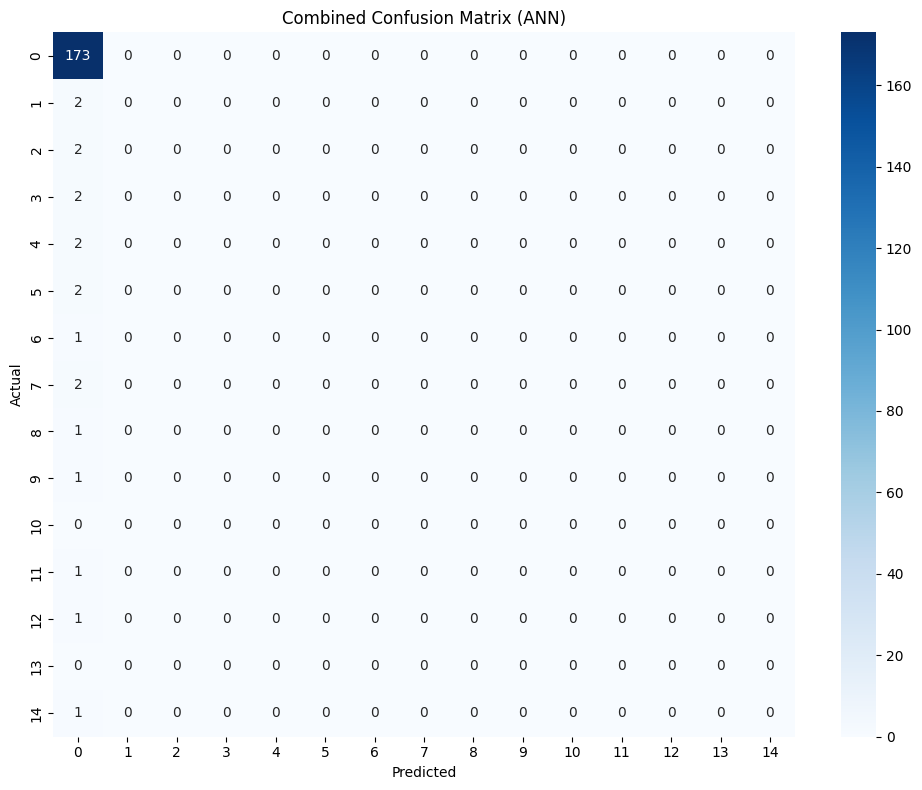


Classification Report:

              precision    recall  f1-score   support

           0       0.65      1.00      0.79       173
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         2
           6       0.00      0.00      0.00         2
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         2
          11       0.00      0.00      0.00         2
          12       0.00      0.00      0.00         2
          13       0.00      0.00      0.00         2
          14       0.00      0.00      0.00         3
          15       0.00      0.00      0.00         2
          16       0.00      0.00      0.00         2
  

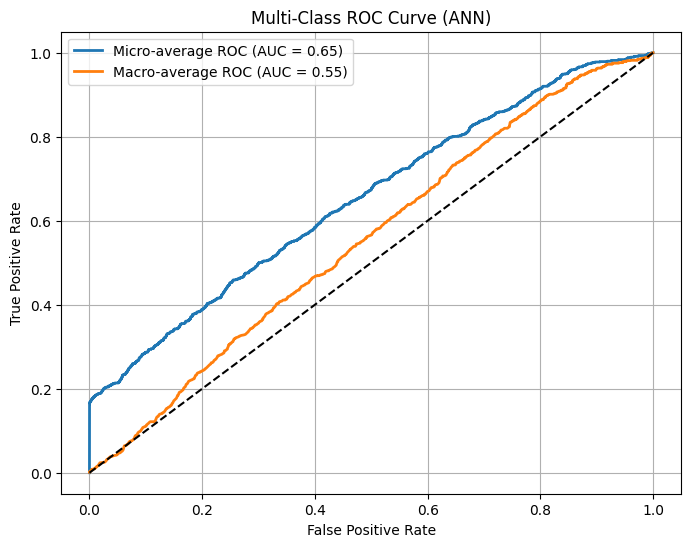


Micro AUC: 0.6507808275776403
Macro AUC: 0.5544839405813777

ANALYSIS COMPLETE ✅


In [ ]:
# ============================================================
# CANCER CLASSIFICATION USING ANN WITH CONFUSION MATRIX & ROC
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from itertools import cycle
import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
print("="*70)
print("CANCER CLASSIFICATION USING ANN (STRATIFIED K-FOLD + ROC)")
print("="*70)

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
data = pd.read_csv("Data_Sets.csv")
print(f"Total Samples: {data.shape[0]}, Total Features: {data.shape[1]-2}")

# ------------------------------------------------------------
# 2. PREPROCESSING
# ------------------------------------------------------------
X = data.iloc[:, 1:-1]
y = data.iloc[:, -1]

X = X.apply(pd.to_numeric, errors='coerce').fillna(X.median())

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Remove single-sample classes
class_counts = pd.Series(y_encoded).value_counts()
valid_classes = class_counts[class_counts >= 2].index
mask = np.isin(y_encoded, valid_classes)
X = X[mask]
y_encoded = y_encoded[mask]

# Re-encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_encoded)
class_names = le.classes_
n_classes = len(class_names)
print(f"Remaining Samples: {len(y_encoded)}, Remaining Classes: {n_classes}")

# Feature Selection
n_features = min(50, X.shape[1])
selector = SelectKBest(score_func=f_classif, k=n_features)
X_selected = selector.fit_transform(X, y_encoded)
print(f"Selected Top {n_features} Genes")

# ------------------------------------------------------------
# 3. DEFINE ANN MODEL
# ------------------------------------------------------------
class GeneANN(nn.Module):
    def __init__(self, input_size, n_classes):
        super(GeneANN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout = nn.Dropout(0.4)
        self.fc3 = nn.Linear(64, n_classes)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(self.relu(self.bn2(self.fc2(x))))
        x = self.fc3(x)
        return x

# ------------------------------------------------------------
# 4. STRATIFIED K-FOLD TRAINING
# ------------------------------------------------------------
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

fold_accuracies = []
all_preds = []
all_true = []
all_probs = []

fold_number = 1

for train_idx, test_idx in skf.split(X_selected, y_encoded):
    print(f"\n========== FOLD {fold_number} ==========")

    # Split
    X_train, X_test = X_selected[train_idx], X_selected[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    # Scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Convert to tensors
    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    y_test = torch.tensor(y_test, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

    # Model
    input_size = X_train.shape[1]
    model = GeneANN(input_size, n_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training
    epochs = 20
    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Evaluation
    model.eval()
    y_pred = []
    y_true = []
    probs_fold = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            prob = torch.softmax(outputs, dim=1)
            probs_fold.extend(prob.numpy())
            _, predicted = torch.max(outputs, 1)
            y_pred.extend(predicted.numpy())
            y_true.extend(labels.numpy())

    accuracy = accuracy_score(y_true, y_pred)
    fold_accuracies.append(accuracy)

    print(f"Fold {fold_number} Accuracy: {accuracy:.4f}")

    all_preds.extend(y_pred)
    all_true.extend(y_true)
    all_probs.extend(probs_fold)

    fold_number += 1

# ------------------------------------------------------------
# 5. FINAL RESULTS
# ------------------------------------------------------------
print("\n" + "="*70)
print(f"Average Cross-Validation Accuracy: {np.mean(fold_accuracies):.4f}")
print("="*70)

# Confusion Matrix
cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(10,8))
if n_classes <= 15:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
else:
    sns.heatmap(cm[:15,:15], annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix (Top 15 Classes Shown)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Combined Confusion Matrix (ANN)")
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(all_true, all_preds))

# ------------------------------------------------------------
# 6. MULTI-CLASS ROC CURVE
# ------------------------------------------------------------
from sklearn.preprocessing import label_binarize
all_true = np.array(all_true)
all_probs = np.array(all_probs)
y_bin = label_binarize(all_true, classes=np.arange(n_classes))

# Compute ROC and AUC
fpr = dict(); tpr = dict(); roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), all_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot ROC
plt.figure(figsize=(8,6))
plt.plot(fpr["micro"], tpr["micro"], label=f"Micro-average ROC (AUC = {roc_auc['micro']:.2f})", linewidth=2)
plt.plot(fpr["macro"], tpr["macro"], label=f"Macro-average ROC (AUC = {roc_auc['macro']:.2f})", linewidth=2)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve (ANN)")
plt.legend()
plt.grid(True)
plt.show()

print("\nMicro AUC:", roc_auc["micro"])
print("Macro AUC:", roc_auc["macro"])
print("\nANALYSIS COMPLETE ✅")